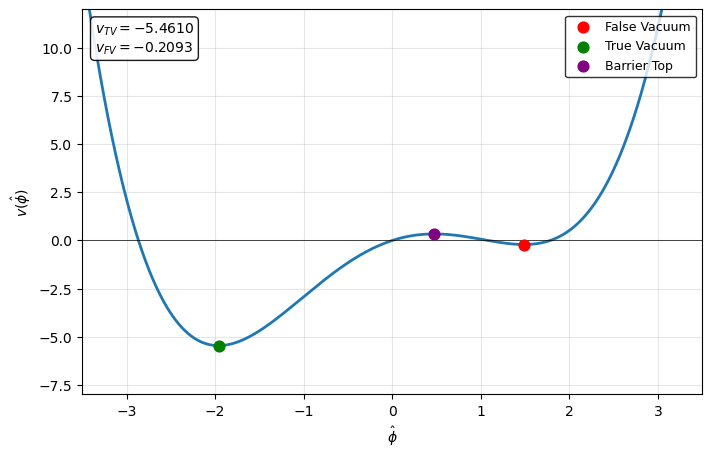


 n |   E_n (rescaled)   |   Lambda_n / H
---------------------------------------------
0 | -6.582807e-05 | -1.667445e-06
1 |  2.608319e-01 |  6.606949e-03
2 |  4.718551e+00 |  1.195223e-01
3 |  9.032383e+00 |  2.287929e-01
4 |  1.139079e+01 |  2.885321e-01


In [13]:

#1D Stochastic Approach#
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import eigsh
from scipy.signal import find_peaks





phi, alpha, beta = sp.symbols("phi alpha beta", real=True)

Omega = 1 + alpha + sp.sqrt(beta)

v_expr = (sp.pi**2 / (3 * Omega)) * (
    4 * alpha * phi
    - 2 * (beta / Omega) * phi**2
    + (4 / Omega**3) * phi**4
)

dv_expr = sp.diff(v_expr, phi)
d2v_expr = sp.diff(dv_expr, phi)
W_expr = sp.Rational(1, 2) * (dv_expr**2 - d2v_expr)

v_num = sp.lambdify((phi, alpha, beta), v_expr, "numpy")
W_num = sp.lambdify((phi, alpha, beta), W_expr, "numpy")





# Parameters
alpha_val = 0.3
beta_val = 1.8
lambda_val = 0.05

Omega_val = 1 + alpha_val + np.sqrt(beta_val)
scale = np.sqrt(lambda_val) * Omega_val**2

# Grid
N = 4001
L = 8.0
phi_vals = np.linspace(-L, L, N)
dphi = phi_vals[1] - phi_vals[0]





# Potential 
v_vals = v_num(phi_vals, alpha_val, beta_val)

if show_W:
    W_vals_inset = W_num(phi_vals, alpha_val, beta_val)





# Find minima of v(phi)
minima_idx, _ = find_peaks(-v_vals)
phi_minima = phi_vals[minima_idx]
v_minima = v_vals[minima_idx]

sorted_minima = np.argsort(v_minima)
true_phi = phi_minima[sorted_minima[0]]
false_phi = phi_minima[sorted_minima[1]]
true_v = v_minima[sorted_minima[0]]
false_v = v_minima[sorted_minima[1]]





# Find the barrier top between the two vacua
left_phi = min(true_phi, false_phi)
right_phi = max(true_phi, false_phi)
between_vacua = (phi_vals > left_phi) & (phi_vals < right_phi)

barrier_idx, _ = find_peaks(v_vals[between_vacua])
phi_barrier = phi_vals[between_vacua][barrier_idx]
v_barrier = v_vals[between_vacua][barrier_idx]

top_idx = np.argmax(v_barrier)
bar_phi = phi_barrier[top_idx]
bar_v = v_barrier[top_idx]





# Plot v(phi)
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(phi_vals, v_vals, lw=2)
ax.scatter(false_phi, false_v, color="red", s=60, zorder=5, label="False Vacuum")
ax.scatter(true_phi, true_v, color="green", s=60, zorder=5, label="True Vacuum")
ax.scatter(bar_phi, bar_v, color="purple", s=60, zorder=5, label="Barrier Top")
ax.axhline(0, color="black", lw=0.5)

ax.set_xlabel(r"$\hat{\phi}$")
ax.set_ylabel(r"$v(\hat{\phi})$")

ax.legend(
    loc="upper right",
    frameon=True,
    facecolor="white",
    edgecolor="black",
    fontsize=9
)

vacuum_info = (
    rf"$v_{{TV}} = {true_v:.4f}$" "\n"
    rf"$v_{{FV}} = {false_v:.4f}$"
)

ax.text(
    0.02, 0.97,
    vacuum_info,
    transform=ax.transAxes,
    fontsize=10,
    va="top",
    ha="left",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.9, edgecolor="black")
)





# Final 
ax.set_xlim(-3.5, 3.5)
ax.set_ylim(-8, 12)
ax.grid(True, alpha=0.3)

plt.show()







# Build W(phi) and solve 
W_vals = W_num(phi_vals, alpha_val, beta_val)

main_diag = np.full(N, -2.0)
off_diag = np.ones(N - 1)

laplacian = diags(
    [off_diag, main_diag, off_diag],
    offsets=[-1, 0, 1],
    format="csr"
) / dphi**2

kinetic = -0.5 * laplacian
potential = diags(W_vals, 0)
hamiltonian = scale * (kinetic + potential)

num_eigs = 5
E_vals, _ = eigsh(hamiltonian, k=num_eigs, sigma=0.0, which="LM")
E_vals = np.sort(E_vals)

Lambda_over_H = E_vals / (4 * np.pi**2)





print("\n n |   E_n (rescaled)   |   Lambda_n / H")
print("-" * 45)
for n in range(num_eigs):
    print(f"{n:1d} | {E_vals[n]: .6e} | {Lambda_over_H[n]: .6e}")

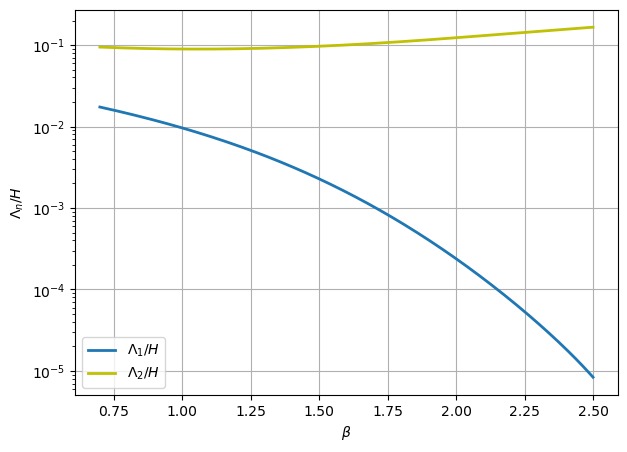

In [14]:

#Decay rate vs. Beta plot in 1D Stochastic#
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import eigsh



# Fixed parameters
alpha_val = 0.1
lambda_val = 0.05



# Range of beta values
beta_vals = np.linspace(0.7, 2.5, 200)

Lambda1 = []
Lambda2 = []



# Grid
N = 4001
L = 8.0
phi_vals = np.linspace(-L, L, N)
dphi = phi_vals[1] - phi_vals[0]



# Kinetic term
main_diag = np.full(N, -2.0)
off_diag = np.ones(N - 1)

laplacian = diags([off_diag, main_diag, off_diag], [-1, 0, 1]) / dphi**2
kinetic = -0.5 * laplacian


# Scan over beta
for beta_val in beta_vals:
    Omega_val = 1 + alpha_val + np.sqrt(beta_val)
    scale = np.sqrt(lambda_val) * Omega_val**2

    W_vals = W_num(phi_vals, alpha_val, beta_val)
    potential = diags(W_vals, 0)

    hamiltonian = scale * (kinetic + potential)

    E_vals, _ = eigsh(hamiltonian, k=3, sigma=0.0, which="LM")
    E_vals = np.sort(E_vals)

    Lambda1.append(E_vals[1] / (4 * np.pi**2))
    Lambda2.append(E_vals[2] / (4 * np.pi**2))


# Plot
plt.figure(figsize=(7, 5))
plt.plot(beta_vals, Lambda1, lw=2, color="tab:blue", label=r"$\Lambda_1/H$")
plt.plot(beta_vals, Lambda2, lw=2, color="y", alpha=0.98, label=r"$\Lambda_2/H$")
plt.xlabel(r"$\beta$")
plt.ylabel(r"$\Lambda_n/H$")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()

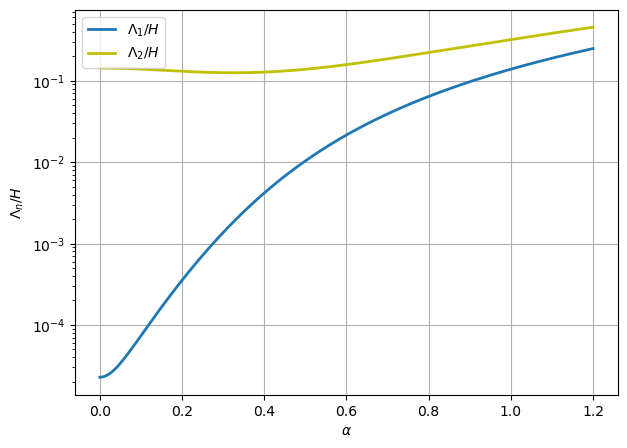

In [15]:

# Decay rate vs. Alpha plot in 1D Stochastic#
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import eigsh


# Fixed parameters
beta_val = 2.2
lambda_val = 0.05


# Range of alpha values
alpha_vals = np.linspace(0.0, 1.2, 200)

Lambda1 = []
Lambda2 = []


# Grid
N = 4001
L = 8.0
phi_vals = np.linspace(-L, L, N)
dphi = phi_vals[1] - phi_vals[0]


# Kinetic term
main_diag = np.full(N, -2.0)
off_diag = np.ones(N - 1)

laplacian = diags([off_diag, main_diag, off_diag], [-1, 0, 1]) / dphi**2
kinetic = -0.5 * laplacian


# Scan over alpha
for alpha_val in alpha_vals:
    Omega_val = 1 + alpha_val + np.sqrt(beta_val)
    scale = np.sqrt(lambda_val) * Omega_val**2

    W_vals = W_num(phi_vals, alpha_val, beta_val)
    potential = diags(W_vals, 0)

    hamiltonian = scale * (kinetic + potential)

    E_vals, _ = eigsh(hamiltonian, k=3, sigma=0.0, which="LM")
    E_vals = np.sort(E_vals)

    Lambda1.append(E_vals[1] / (4 * np.pi**2))
    Lambda2.append(E_vals[2] / (4 * np.pi**2))


# Plot
plt.figure(figsize=(7, 5))
plt.plot(alpha_vals, Lambda1, lw=2, color="tab:blue", label=r"$\Lambda_1/H$")
plt.plot(alpha_vals, Lambda2, lw=2, color="y", alpha=0.98, label=r"$\Lambda_2/H$")
plt.xlabel(r"$\alpha$")
plt.ylabel(r"$\Lambda_n/H$")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()

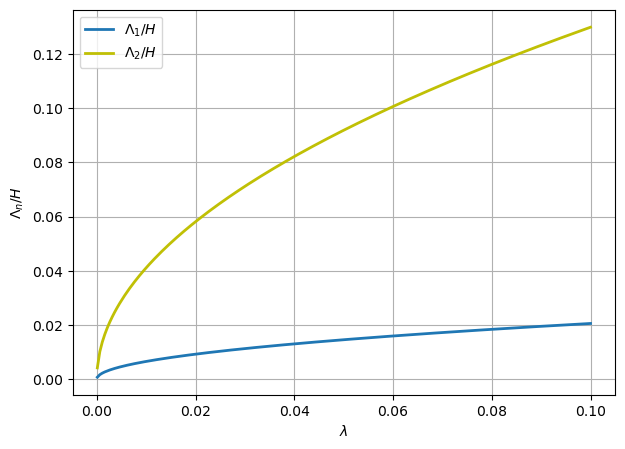

In [16]:

# Decay rate vs. Lambda plot in 1D Stochastic#
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import eigsh


# Fixed parameters
alpha_val = 0.1
beta_val = 0.8


# Range of lambda values
lambda_vals = np.linspace(1e-4, 0.1, 200)

Lambda1 = []
Lambda2 = []


# Grid
N = 4001
L = 8.0
phi_vals = np.linspace(-L, L, N)
dphi = phi_vals[1] - phi_vals[0]


# Kinetic term
main_diag = np.full(N, -2.0)
off_diag = np.ones(N - 1)

laplacian = diags([off_diag, main_diag, off_diag], [-1, 0, 1]) / dphi**2
kinetic = -0.5 * laplacian


# Scan over lambda
for lambda_val in lambda_vals:
    Omega_val = 1 + alpha_val + np.sqrt(beta_val)
    scale = np.sqrt(lambda_val) * Omega_val**2

    W_vals = W_num(phi_vals, alpha_val, beta_val)
    potential = diags(W_vals, 0)

    hamiltonian = scale * (kinetic + potential)

    E_vals, _ = eigsh(hamiltonian, k=3, sigma=0.0, which="LM")
    E_vals = np.sort(E_vals)

    Lambda1.append(E_vals[1] / (4 * np.pi**2))
    Lambda2.append(E_vals[2] / (4 * np.pi**2))


# Plot
plt.figure(figsize=(7, 5))
plt.plot(lambda_vals, Lambda1, lw=2, color="tab:blue", label=r"$\Lambda_1/H$")
plt.plot(lambda_vals, Lambda2, lw=2, color="y", alpha=0.98, label=r"$\Lambda_2/H$")
plt.xlabel(r"$\lambda$")
plt.ylabel(r"$\Lambda_n/H$")
plt.grid(True)
plt.legend()
plt.show()

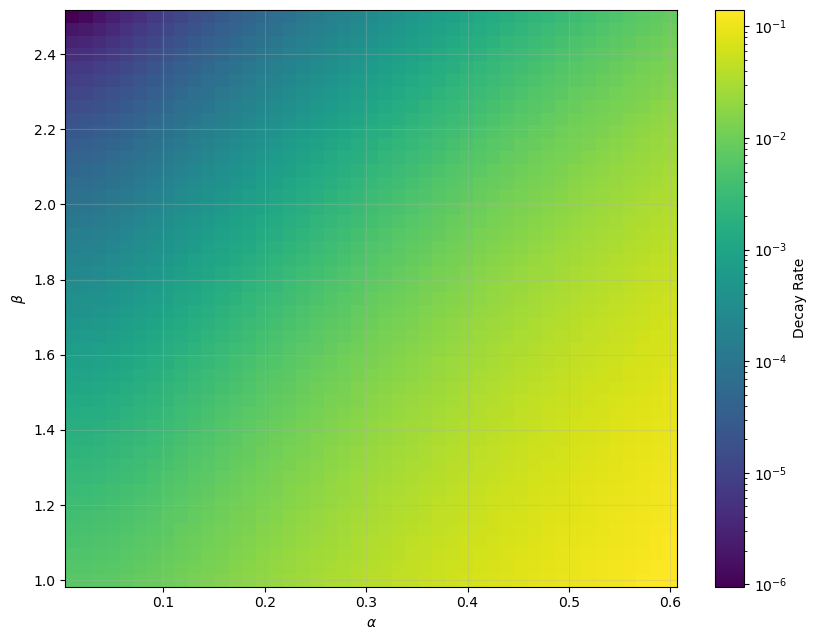

In [19]:

#HeatMap#
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.sparse import diags
from scipy.sparse.linalg import eigsh


# Grid
N = 4001
L = 8.0
phi_vals = np.linspace(-L, L, N)
dphi = phi_vals[1] - phi_vals[0]

main_diag = np.full(N, -2.0)
off_diag = np.ones(N - 1)

laplacian = diags([off_diag, main_diag, off_diag], [-1, 0, 1]) / dphi**2
kinetic = -0.5 * laplacian

#_______________________________________________________________________________
def Omega(alpha, beta):
    return 1 + alpha + np.sqrt(beta)


def v_shape(phi, alpha, beta):
    Om = Omega(alpha, beta)
    return (np.pi**2 / (3 * Om)) * (
        4 * alpha * phi
        - 2 * (beta / Om) * phi**2
        + (4 / Om**3) * phi**4
    )


def W(phi, alpha, beta):
    Om = Omega(alpha, beta)

    v1 = (np.pi**2 / (3 * Om)) * (
        4 * alpha
        - 4 * (beta / Om) * phi
        + (16 / Om**3) * phi**3
    )

    v2 = (np.pi**2 / (3 * Om)) * (
        -4 * beta / Om
        + 48 * phi**2 / Om**3
    )

    return 0.5 * (v1**2 - v2)


def Lambda1_over_H(alpha, beta, lambda_val):
    Om = Omega(alpha, beta)
    scale = np.sqrt(lambda_val) * Om**2

    W_vals = W(phi_vals, alpha, beta)
    potential = diags(W_vals, 0)

    hamiltonian = scale * (kinetic + potential)

    E_vals, _ = eigsh(hamiltonian, k=3, sigma=0.0, which="LM")
    E_vals = np.sort(E_vals)

    return E_vals[1] / (4 * np.pi**2)


def find_extrema(alpha, beta):
    Om = Omega(alpha, beta)

    p = -(beta * Om**2) / 4
    q = (alpha * Om**3) / 4

    roots = np.roots([1, 0, p, q])
    roots = [r.real for r in roots if abs(r.imag) < 1e-10]

    return sorted(roots)


def Gamma_HM(alpha, beta):
    roots = find_extrema(alpha, beta)
    if len(roots) < 3:
        return np.nan

    Om = Omega(alpha, beta)

    def v_full(phi):
        V0 = 4 * np.pi**2 / (1e-3)**2
        return V0 + v_shape(phi, alpha, beta)

    def d2v(phi):
        return (np.pi**2 / (3 * Om)) * (
            -4 * beta / Om
            + 48 * phi**2 / Om**3
        )

    mins = [r for r in roots if d2v(r) > 0]
    maxs = [r for r in roots if d2v(r) < 0]

    if len(mins) < 2:
        return np.nan

    vmins = sorted([(x, v_full(x)) for x in mins], key=lambda t: t[1])
    phi_true, v_true = vmins[0]
    phi_false, v_false = vmins[1]

    lo, hi = sorted([phi_true, phi_false])
    tops = [x for x in maxs if lo < x < hi]

    if len(tops) == 0:
        return np.nan

    phi_top = tops[0]
    Delta_v = v_full(phi_top) - v_false
    B = 2 * Delta_v

    return np.exp(-B)
#_________________________________________________________________________________





# Scan ranges
alpha_vals = np.linspace(0.01, 0.6, 45)
beta_vals = np.linspace(1.0, 2.5, 45)

lambda_val = 0.05

Z_stoch = np.full((len(beta_vals), len(alpha_vals)), np.nan)
Z_hm = np.full((len(beta_vals), len(alpha_vals)), np.nan)

for i, beta in enumerate(beta_vals):
    for j, alpha in enumerate(alpha_vals):
        try:
            Z_stoch[i, j] = Lambda1_over_H(alpha, beta, lambda_val)
        except Exception:
            Z_stoch[i, j] = np.nan

        Z_hm[i, j] = Gamma_HM(alpha, beta)


def positive_finite(arr):
    mask = np.isfinite(arr) & (arr > 0)
    return arr[mask]


vals = positive_finite(Z_stoch)
if vals.size == 0:
    raise RuntimeError("No positive finite stochastic decay-rate values to plot.")

vmin = np.nanmin(vals)
vmax = np.nanmax(vals)

A, B = np.meshgrid(alpha_vals, beta_vals)

fig, ax = plt.subplots(figsize=(8.5, 6.5))

im = ax.pcolormesh(
    A,
    B,
    Z_stoch,
    shading="auto",
    norm=LogNorm(vmin=vmin, vmax=vmax)
)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r"Decay Rate")



ax.set_xlabel(r"$\alpha$")
ax.set_ylabel(r"$\beta$")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("Heatmap", dpi=300, bbox_inches="tight")
plt.show()

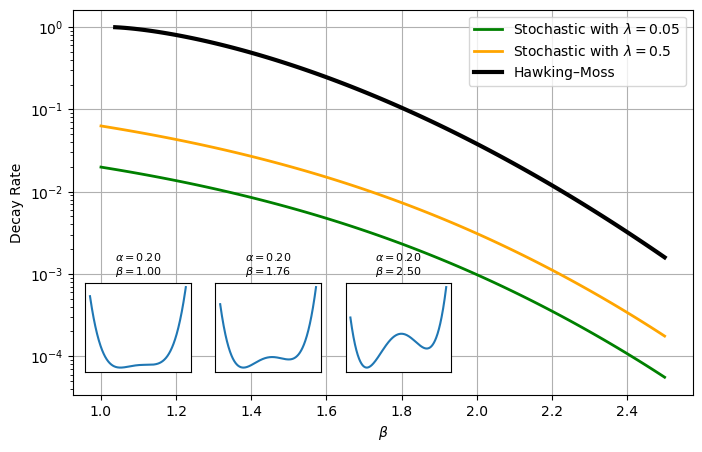

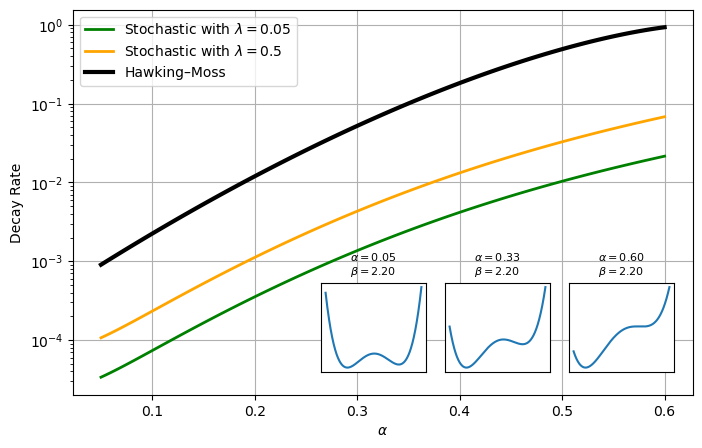

In [22]:

#HM with Stochastic#
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import eigsh


# Grid
N = 4001
L = 8.0
phi_vals = np.linspace(-L, L, N)
dphi = phi_vals[1] - phi_vals[0]

main_diag = np.full(N, -2.0)
off_diag = np.ones(N - 1)

laplacian = diags([off_diag, main_diag, off_diag], [-1, 0, 1]) / dphi**2
kinetic = -0.5 * laplacian



#_______________________________________
def Omega(alpha, beta):
    return 1 + alpha + np.sqrt(beta)


def v_shape(phi, alpha, beta):
    Om = Omega(alpha, beta)
    return (np.pi**2 / (3 * Om)) * (
        4 * alpha * phi
        - 2 * (beta / Om) * phi**2
        + (4 / Om**3) * phi**4
    )


def W(phi, alpha, beta):
    Om = Omega(alpha, beta)

    v1 = (np.pi**2 / (3 * Om)) * (
        4 * alpha
        - 4 * (beta / Om) * phi
        + (16 / Om**3) * phi**3
    )

    v2 = (np.pi**2 / (3 * Om)) * (
        -4 * beta / Om
        + 48 * phi**2 / Om**3
    )

    return 0.5 * (v1**2 - v2)


def Lambda1_over_H(alpha, beta, lambda_val):
    Om = Omega(alpha, beta)
    scale = np.sqrt(lambda_val) * Om**2

    W_vals = W(phi_vals, alpha, beta)
    potential = diags(W_vals, 0)

    hamiltonian = scale * (kinetic + potential)

    E_vals, _ = eigsh(hamiltonian, k=3, sigma=0.0, which="LM")
    E_vals = np.sort(E_vals)

    return E_vals[1] / (4 * np.pi**2)


def find_extrema(alpha, beta):
    Om = Omega(alpha, beta)

    p = -(beta * Om**2) / 4
    q = (alpha * Om**3) / 4

    roots = np.roots([1, 0, p, q])
    roots = [r.real for r in roots if abs(r.imag) < 1e-10]

    return sorted(roots)


def Gamma_HM(alpha, beta):
    roots = find_extrema(alpha, beta)
    if len(roots) < 3:
        return np.nan

    Om = Omega(alpha, beta)

    def v_full(phi):
        V0 = 4 * np.pi**2 / (1e-3)**2
        return V0 + v_shape(phi, alpha, beta)

    def d2v(phi):
        return (np.pi**2 / (3 * Om)) * (
            -4 * beta / Om
            + 48 * phi**2 / Om**3
        )

    mins = [r for r in roots if d2v(r) > 0]
    maxs = [r for r in roots if d2v(r) < 0]

    if len(mins) < 2:
        return np.nan

    vmins = sorted([(x, v_full(x)) for x in mins], key=lambda t: t[1])

    phi_true, v_true = vmins[0]
    phi_false, v_false = vmins[1]

    lo, hi = sorted([phi_true, phi_false])
    tops = [x for x in maxs if lo < x < hi]

    if len(tops) == 0:
        return np.nan

    phi_top = tops[0]
    Delta_v = v_full(phi_top) - v_false
    B = 2 * Delta_v

    return np.exp(-B)


def draw_potential_inset(ax, alpha, beta, pos):
    axins = ax.inset_axes(pos)

    phi_plot = np.linspace(-3.5, 3.5, 500)
    v_plot = v_shape(phi_plot, alpha, beta)

    axins.plot(phi_plot, v_plot, lw=1.5)
    axins.set_xticks([])
    axins.set_yticks([])
    axins.set_title(
        rf"$\alpha={alpha:.2f}$" + "\n" + rf"$\beta={beta:.2f}$",
        fontsize=8
    )
    axins.grid(True, alpha=0.3)
#___________________________________________________________




lambdas = [0.05, 0.5]


# Comparison as a function of beta
alpha_fixed = 0.2
beta_vals = np.linspace(1.0, 2.5, 120)

Gamma_vals = [Gamma_HM(alpha_fixed, b) for b in beta_vals]

fig, ax = plt.subplots(figsize=(8, 5))

for lambda_val in lambdas:
    Lambda_vals = [Lambda1_over_H(alpha_fixed, b, lambda_val) for b in beta_vals]

    ax.plot(
        beta_vals,
        Lambda_vals,
        lw=2,
        color="green" if lambda_val == 0.05 else "orange",
        label=rf"Stochastic with $\lambda={lambda_val}$"
    )




ax.plot(beta_vals, Gamma_vals, lw=3, color="black", label="Hawking–Moss")
ax.set_xlabel(r"$\beta$")
ax.set_ylabel("Decay Rate")
ax.legend()
ax.grid(True)
ax.set_yscale("log")

draw_potential_inset(ax, alpha_fixed, beta_vals[0], [0.02, 0.06, 0.17, 0.23])
draw_potential_inset(ax, alpha_fixed, beta_vals[len(beta_vals) // 2], [0.23, 0.06, 0.17, 0.23])
draw_potential_inset(ax, alpha_fixed, beta_vals[-1], [0.44, 0.06, 0.17, 0.23])

plt.show()


# Comparison as a function of alpha
beta_fixed = 2.2
alpha_vals = np.linspace(0.05, 0.6, 120)

Gamma_vals = [Gamma_HM(a, beta_fixed) for a in alpha_vals]

fig, ax = plt.subplots(figsize=(8, 5))

for lambda_val in lambdas:
    Lambda_vals = [Lambda1_over_H(a, beta_fixed, lambda_val) for a in alpha_vals]

    ax.plot(
        alpha_vals,
        Lambda_vals,
        lw=2,
        color="green" if lambda_val == 0.05 else "orange",
        label=rf"Stochastic with $\lambda={lambda_val}$"
    )

ax.plot(alpha_vals, Gamma_vals, lw=3, color="black", label="Hawking–Moss")
ax.set_xlabel(r"$\alpha$")
ax.set_ylabel("Decay Rate")
ax.legend()
ax.grid(True)
ax.set_yscale("log")

draw_potential_inset(ax, alpha_vals[0], beta_fixed, [0.40, 0.06, 0.17, 0.23])
draw_potential_inset(ax, alpha_vals[len(alpha_vals) // 2], beta_fixed, [0.60, 0.06, 0.17, 0.23])
draw_potential_inset(ax, alpha_vals[-1], beta_fixed, [0.80, 0.06, 0.17, 0.23])

plt.show()

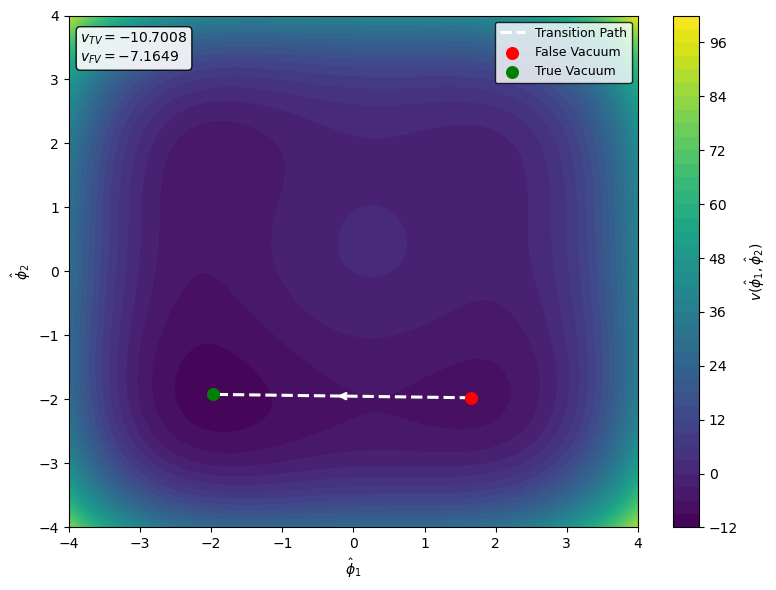


 n |   E_n (rescaled)   |   Lambda_n / H
---------------------------------------------
0 | -1.980414e-02 | -5.016447e-04
1 |  7.591531e-02 |  1.922957e-03
2 |  3.854115e-01 |  9.762588e-03
3 |  4.660340e-01 |  1.180478e-02
4 |  4.271057e+00 |  1.081871e-01
5 |  4.306474e+00 |  1.090843e-01


In [25]:

#2D Stochastic#
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from scipy.sparse import diags, eye, kron
from scipy.sparse.linalg import eigsh


phi1, phi2 = sp.symbols("phi1 phi2", real=True)
alpha, beta, delta, gamma, xi = sp.symbols("alpha beta delta gamma xi", real=True)

Omega = 1 + alpha + sp.sqrt(beta)
Omega_p = 1 + delta + sp.sqrt(gamma)

v_expr = (
    (sp.pi**2 / (3 * Omega)) * (
        4 * alpha * phi1
        - 2 * (beta / Omega) * phi1**2
        + (4 / Omega**3) * phi1**4
    )
    +
    (sp.pi**2 / (3 * Omega_p)) * (
        4 * delta * phi2
        - 2 * (gamma / Omega_p) * phi2**2
        + (4 / Omega_p**3) * phi2**4
    )
    +
    (sp.pi**2 / (3 * Omega * Omega_p)) * xi * phi1**2 * phi2**2
)

dv1_expr = sp.diff(v_expr, phi1)
dv2_expr = sp.diff(v_expr, phi2)
d2v11_expr = sp.diff(dv1_expr, phi1)
d2v22_expr = sp.diff(dv2_expr, phi2)

v_num = sp.lambdify((phi1, phi2, alpha, beta, delta, gamma, xi), v_expr, "numpy")
v1_num = sp.lambdify((phi1, phi2, alpha, beta, delta, gamma, xi), dv1_expr, "numpy")
v2_num = sp.lambdify((phi1, phi2, alpha, beta, delta, gamma, xi), dv2_expr, "numpy")
v11_num = sp.lambdify((phi1, phi2, alpha, beta, delta, gamma, xi), d2v11_expr, "numpy")
v22_num = sp.lambdify((phi1, phi2, alpha, beta, delta, gamma, xi), d2v22_expr, "numpy")
#___________________________________________________________

# Parameters
alpha_val = 0.2
beta_val = 2.2

delta_val = 0.3
gamma_val = 2.0

xi_val = 0.2
lambda_val = 0.05

Omega_val = 1 + alpha_val + np.sqrt(beta_val)
Omega_p_val = 1 + delta_val + np.sqrt(gamma_val)

scale1 = np.sqrt(lambda_val) * Omega_val**2
scale2 = np.sqrt(lambda_val) * Omega_p_val**2


# 2D grid
N1 = 151
N2 = 151

L1 = 4.0
L2 = 4.0

phi1_vals = np.linspace(-L1, L1, N1)
phi2_vals = np.linspace(-L2, L2, N2)

dphi1 = phi1_vals[1] - phi1_vals[0]
dphi2 = phi2_vals[1] - phi2_vals[0]

PHI1, PHI2 = np.meshgrid(phi1_vals, phi2_vals, indexing="ij")




# Potential and W 
v_vals = v_num(PHI1, PHI2, alpha_val, beta_val, delta_val, gamma_val, xi_val)

v1_vals = v1_num(PHI1, PHI2, alpha_val, beta_val, delta_val, gamma_val, xi_val)
v2_vals = v2_num(PHI1, PHI2, alpha_val, beta_val, delta_val, gamma_val, xi_val)
v11_vals = v11_num(PHI1, PHI2, alpha_val, beta_val, delta_val, gamma_val, xi_val)
v22_vals = v22_num(PHI1, PHI2, alpha_val, beta_val, delta_val, gamma_val, xi_val)

W_vals = 0.5 * (
    scale1 * (v1_vals**2 - v11_vals)
    + scale2 * (v2_vals**2 - v22_vals)
)




# Find minima
local_min_mask = np.ones_like(v_vals, dtype=bool)

for di in [-1, 0, 1]:
    for dj in [-1, 0, 1]:
        if di == 0 and dj == 0:
            continue
        shifted = np.roll(np.roll(v_vals, di, axis=0), dj, axis=1)
        local_min_mask &= (v_vals <= shifted)

local_min_mask[0, :] = False
local_min_mask[-1, :] = False
local_min_mask[:, 0] = False
local_min_mask[:, -1] = False

min_indices = np.argwhere(local_min_mask)


if len(min_indices) < 2:
    raise RuntimeError("Could not find at least two local minima on this grid.")

min_points = []
for i, j in min_indices:
    min_points.append((phi1_vals[i], phi2_vals[j], v_vals[i, j]))

min_points.sort(key=lambda x: x[2])

true_phi1, true_phi2, true_v = min_points[0]
false_phi1, false_phi2, false_v = min_points[1]





# Transition path
num_path = 300
s_vals = np.linspace(0.0, 1.0, num_path)

phi1_path = false_phi1 + (true_phi1 - false_phi1) * s_vals
phi2_path = false_phi2 + (true_phi2 - false_phi2) * s_vals





# Plot v(phi1, phi2)
fig, ax = plt.subplots(figsize=(8, 6))

cont = ax.contourf(PHI1, PHI2, v_vals, levels=40)
cbar = plt.colorbar(cont, ax=ax)
cbar.set_label(r"$v(\hat{\phi}_1,\hat{\phi}_2)$")

ax.plot(phi1_path, phi2_path, "w--", lw=2.2, label="Transition Path")
ax.scatter(false_phi1, false_phi2, color="red", s=70, zorder=5, label="False Vacuum")
ax.scatter(true_phi1, true_phi2, color="green", s=70, zorder=5, label="True Vacuum")

mid = len(phi1_path) // 2
ax.annotate(
    "",
    xy=(phi1_path[mid + 8], phi2_path[mid + 8]),
    xytext=(phi1_path[mid - 8], phi2_path[mid - 8]),
    arrowprops=dict(arrowstyle="->", color="white", lw=2)
)

ax.set_xlabel(r"$\hat{\phi}_1$")
ax.set_ylabel(r"$\hat{\phi}_2$")

ax.legend(
    loc="upper right",
    frameon=True,
    facecolor="white",
    edgecolor="black",
    fontsize=9
)

textstr = (
    rf"$v_{{TV}} = {true_v:.4f}$" "\n"
    rf"$v_{{FV}} = {false_v:.4f}$"
)

ax.text(
    0.02, 0.97,
    textstr,
    transform=ax.transAxes,
    fontsize=10,
    va="top",
    ha="left",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.9, edgecolor="black")
)
plt.tight_layout()
plt.show()




# Build the 2D Hamiltonian and solve the spectrum
main_diag_1 = np.full(N1, -2.0)
off_diag_1 = np.ones(N1 - 1)
lap1 = diags([off_diag_1, main_diag_1, off_diag_1], [-1, 0, 1], format="csr") / dphi1**2

main_diag_2 = np.full(N2, -2.0)
off_diag_2 = np.ones(N2 - 1)
lap2 = diags([off_diag_2, main_diag_2, off_diag_2], [-1, 0, 1], format="csr") / dphi2**2

I1 = eye(N1, format="csr")
I2 = eye(N2, format="csr")

T1 = -0.5 * scale1 * kron(lap1, I2, format="csr")
T2 = -0.5 * scale2 * kron(I1, lap2, format="csr")
kinetic = T1 + T2

potential = diags(W_vals.reshape(N1 * N2), 0, format="csr")
hamiltonian = kinetic + potential

num_eigs = 6
E_vals, _ = eigsh(hamiltonian, k=num_eigs, sigma=0.0, which="LM")
E_vals = np.sort(E_vals)

Lambda_over_H = E_vals / (4 * np.pi**2)





print("\n n |   E_n (rescaled)   |   Lambda_n / H")
print("-" * 45)
for n in range(num_eigs):
    print(f"{n:1d} | {E_vals[n]: .6e} | {Lambda_over_H[n]: .6e}")

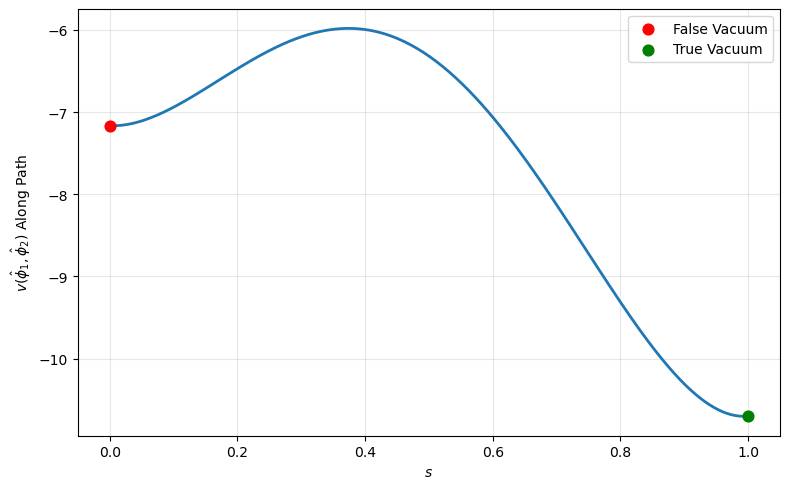

In [27]:

#Transition Path#
num_path = 300
s_vals = np.linspace(0.0, 1.0, num_path)

phi1_path = false_phi1 + (true_phi1 - false_phi1) * s_vals
phi2_path = false_phi2 + (true_phi2 - false_phi2) * s_vals

v_path = v_num(phi1_path, phi2_path, alpha_val, beta_val, delta_val, gamma_val, xi_val)


fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(s_vals, v_path, lw=2)
ax.scatter(0, v_path[0], color="red", s=60, zorder=5, label="False Vacuum")
ax.scatter(1, v_path[-1], color="green", s=60, zorder=5, label="True Vacuum")
ax.set_xlabel(r"$s$")
ax.set_ylabel(r"$v(\hat{\phi}_1,\hat{\phi}_2)$ Along Path")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


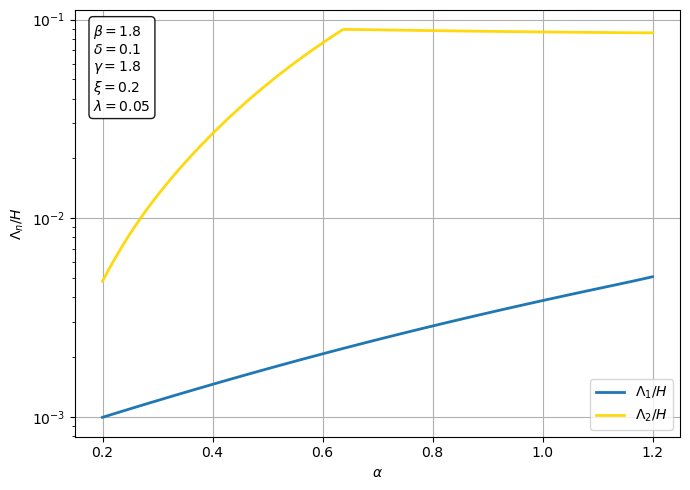

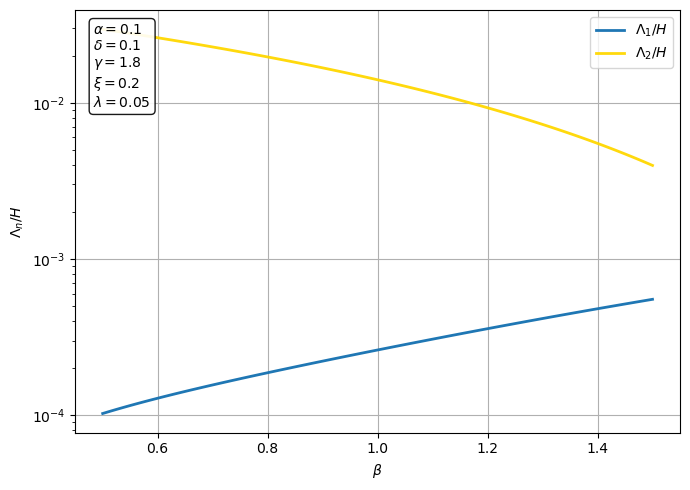

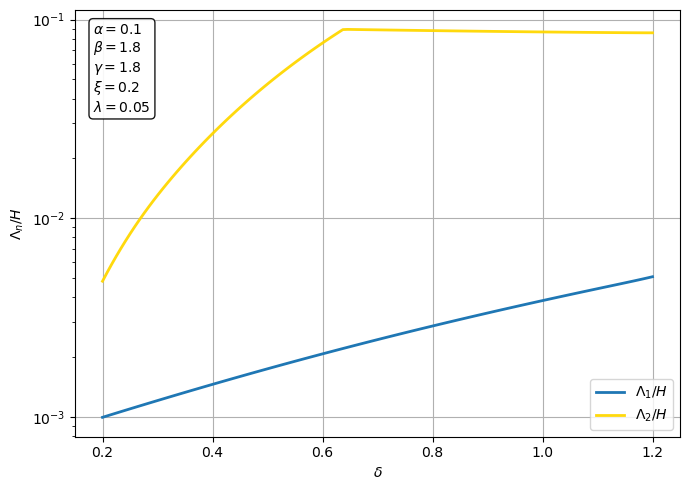

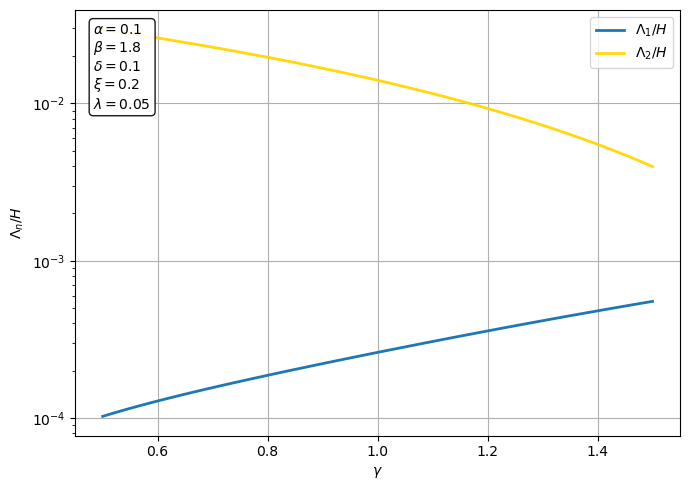

In [28]:

#Decay rate vs. parameters in 2D Stochastic#
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags, eye, kron
from scipy.sparse.linalg import eigsh


# Fixed parameters
alpha_fixed = 0.1
beta_fixed = 1.8
delta_fixed = 0.1
gamma_fixed = 1.8
xi_fixed = 0.2
lambda_fixed = 0.05


# Scan grid
N1_scan = 81
N2_scan = 81
L1_scan = 4.0
L2_scan = 4.0

phi1_scan = np.linspace(-L1_scan, L1_scan, N1_scan)
phi2_scan = np.linspace(-L2_scan, L2_scan, N2_scan)

dphi1_scan = phi1_scan[1] - phi1_scan[0]
dphi2_scan = phi2_scan[1] - phi2_scan[0]

PHI1_scan, PHI2_scan = np.meshgrid(phi1_scan, phi2_scan, indexing="ij")


# 1D 
main_diag_1 = np.full(N1_scan, -2.0)
off_diag_1 = np.ones(N1_scan - 1)
lap1_scan = diags([off_diag_1, main_diag_1, off_diag_1], [-1, 0, 1], format="csr") / dphi1_scan**2

main_diag_2 = np.full(N2_scan, -2.0)
off_diag_2 = np.ones(N2_scan - 1)
lap2_scan = diags([off_diag_2, main_diag_2, off_diag_2], [-1, 0, 1], format="csr") / dphi2_scan**2

I1_scan = eye(N1_scan, format="csr")
I2_scan = eye(N2_scan, format="csr")

#____________________________________________________________________________
def compute_lambda12_over_H(alpha_val, beta_val, delta_val, gamma_val, xi_val, lambda_val,
                            k_eigs=6, zero_tol=1e-10):
    if beta_val <= 0 or gamma_val <= 0 or lambda_val <= 0:
        return np.nan, np.nan

    Omega_val = 1 + alpha_val + np.sqrt(beta_val)
    Omega_p_val = 1 + delta_val + np.sqrt(gamma_val)

    scale1 = np.sqrt(lambda_val) * Omega_val**2
    scale2 = np.sqrt(lambda_val) * Omega_p_val**2

    v1_vals = v1_num(PHI1_scan, PHI2_scan, alpha_val, beta_val, delta_val, gamma_val, xi_val)
    v2_vals = v2_num(PHI1_scan, PHI2_scan, alpha_val, beta_val, delta_val, gamma_val, xi_val)
    v11_vals = v11_num(PHI1_scan, PHI2_scan, alpha_val, beta_val, delta_val, gamma_val, xi_val)
    v22_vals = v22_num(PHI1_scan, PHI2_scan, alpha_val, beta_val, delta_val, gamma_val, xi_val)

    W_vals = 0.5 * (
        scale1 * (v1_vals**2 - v11_vals)
        + scale2 * (v2_vals**2 - v22_vals)
    )

    T1 = -0.5 * scale1 * kron(lap1_scan, I2_scan, format="csr")
    T2 = -0.5 * scale2 * kron(I1_scan, lap2_scan, format="csr")
    kinetic = T1 + T2

    potential = diags(W_vals.reshape(N1_scan * N2_scan), 0, format="csr")
    hamiltonian = kinetic + potential

    E_vals, _ = eigsh(hamiltonian, k=k_eigs, sigma=0.0, which="LM")
    E_vals = np.sort(E_vals)

    Lambda_over_H = E_vals / (4 * np.pi**2)
    positive_modes = Lambda_over_H[Lambda_over_H > zero_tol]

    if len(positive_modes) < 2:
        return np.nan, np.nan

    return positive_modes[0], positive_modes[1]


def make_scan_plot(xvals, label, param_name):
    Lambda1 = []
    Lambda2 = []

    for val in xvals:
        a = alpha_fixed
        b = beta_fixed
        d = delta_fixed
        g = gamma_fixed
        x = xi_fixed
        lam = lambda_fixed

        if param_name == "alpha":
            a = val
        elif param_name == "beta":
            b = val
        elif param_name == "delta":
            d = val
        elif param_name == "gamma":
            g = val

        lam1, lam2 = compute_lambda12_over_H(a, b, d, g, x, lam)
        Lambda1.append(lam1)
        Lambda2.append(lam2)

    Lambda1 = np.array(Lambda1)
    Lambda2 = np.array(Lambda2)

    mask = np.isfinite(Lambda1) & np.isfinite(Lambda2) & (Lambda1 > 0) & (Lambda2 > 0)

    plt.figure(figsize=(7, 5))

    plt.plot(xvals[mask], Lambda1[mask], lw=2, color="tab:blue", label=r"$\Lambda_1/H$")
    plt.plot(xvals[mask], Lambda2[mask], lw=2, color="gold", alpha=0.95, label=r"$\Lambda_2/H$")

    plt.xlabel(label)
    plt.ylabel(r"$\Lambda_n/H$")
    plt.yscale("log")
    plt.grid(True)
    plt.legend()

    fixed_lines = []

    if param_name != "alpha":
        fixed_lines.append(rf"$\alpha = {alpha_fixed}$")
    if param_name != "beta":
        fixed_lines.append(rf"$\beta = {beta_fixed}$")
    if param_name != "delta":
        fixed_lines.append(rf"$\delta = {delta_fixed}$")
    if param_name != "gamma":
        fixed_lines.append(rf"$\gamma = {gamma_fixed}$")

    fixed_lines.append(rf"$\xi = {xi_fixed}$")
    fixed_lines.append(rf"$\lambda = {lambda_fixed}$")

    fixed_text = "\n".join(fixed_lines)

    plt.text(
        0.03, 0.97,
        fixed_text,
        transform=plt.gca().transAxes,
        fontsize=10,
        va="top",
        ha="left",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.9, edgecolor="black")
    )

    plt.tight_layout()
    plt.show()

_________________________________________________________________________
# Plots
alpha_vals = np.linspace(0.2, 1.2, 120)
beta_vals = np.linspace(0.5, 1.5, 120)
delta_vals = np.linspace(0.2, 1.2, 120)
gamma_vals = np.linspace(0.5, 1.5, 120)

make_scan_plot(alpha_vals, r"$\alpha$", "alpha")
make_scan_plot(beta_vals, r"$\beta$", "beta")
make_scan_plot(delta_vals, r"$\delta$", "delta")
make_scan_plot(gamma_vals, r"$\gamma$", "gamma")

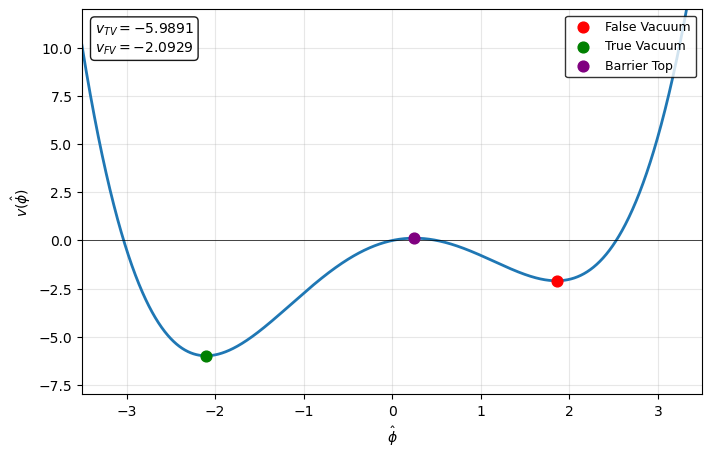


 n |   E_n (rescaled)   |   Lambda_n / H
---------------------------------------------
0 | -7.328028e-05 | -1.856211e-06
1 |  1.396925e-02 |  3.538453e-04
2 |  5.156140e+00 |  1.306066e-01
3 |  8.739815e+00 |  2.213821e-01
4 |  1.214467e+01 |  3.076280e-01


/tmp/ipykernel_209905/615970641.py:227: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm = np.sqrt(np.trapz(np.abs(psi)**2, phi_vals))


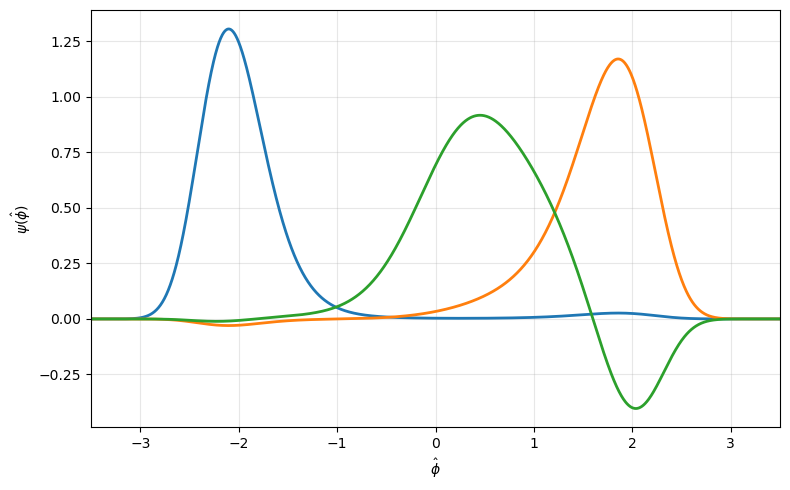

In [31]:

#Eigenfunctions / Potential#
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import eigsh
from scipy.signal import find_peaks



show_W = False

show_psi0 = True
show_psi1 = True
show_psi2 = True
show_psi3 = False
show_psi4 = False





phi, alpha, beta = sp.symbols("phi alpha beta", real=True)
Omega = 1 + alpha + sp.sqrt(beta)

v_expr = (sp.pi**2 / (3 * Omega)) * (
    4 * alpha * phi
    - 2 * (beta / Omega) * phi**2
    + (4 / Omega**3) * phi**4
)

dv_expr = sp.diff(v_expr, phi)
d2v_expr = sp.diff(dv_expr, phi)
W_expr = sp.Rational(1, 2) * (dv_expr**2 - d2v_expr)

v_num = sp.lambdify((phi, alpha, beta), v_expr, "numpy")
W_num = sp.lambdify((phi, alpha, beta), W_expr, "numpy")


# Parameters
alpha_val = 0.2
beta_val = 2.2
lambda_val = 0.05

Omega_val = 1 + alpha_val + np.sqrt(beta_val)
scale = np.sqrt(lambda_val) * Omega_val**2


# Grid
N = 4001
L = 8.0
phi_vals = np.linspace(-L, L, N)
dphi = phi_vals[1] - phi_vals[0]


# Potential
v_vals = v_num(phi_vals, alpha_val, beta_val)

if show_W:
    W_vals_inset = W_num(phi_vals, alpha_val, beta_val)


# Minima of v(phi)
minima_idx, _ = find_peaks(-v_vals)
phi_minima = phi_vals[minima_idx]
v_minima = v_vals[minima_idx]

sorted_minima = np.argsort(v_minima)
true_phi = phi_minima[sorted_minima[0]]
false_phi = phi_minima[sorted_minima[1]]
true_v = v_minima[sorted_minima[0]]
false_v = v_minima[sorted_minima[1]]


# Barrier top between the two vacua
left_phi = min(true_phi, false_phi)
right_phi = max(true_phi, false_phi)
between_vacua = (phi_vals > left_phi) & (phi_vals < right_phi)

barrier_idx, _ = find_peaks(v_vals[between_vacua])
phi_barrier = phi_vals[between_vacua][barrier_idx]
v_barrier = v_vals[between_vacua][barrier_idx]

top_idx = np.argmax(v_barrier)
bar_phi = phi_barrier[top_idx]
bar_v = v_barrier[top_idx]


# Plot v(phi)
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(phi_vals, v_vals, lw=2)
ax.scatter(false_phi, false_v, color="red", s=60, zorder=5, label="False Vacuum")
ax.scatter(true_phi, true_v, color="green", s=60, zorder=5, label="True Vacuum")
ax.scatter(bar_phi, bar_v, color="purple", s=60, zorder=5, label="Barrier Top")
ax.axhline(0, color="black", lw=0.5)

ax.set_xlabel(r"$\hat{\phi}$")
ax.set_ylabel(r"$v(\hat{\phi})$")

ax.legend(
    loc="upper right",
    frameon=True,
    facecolor="white",
    edgecolor="black",
    fontsize=9
)

textstr = (
    rf"$v_{{TV}} = {true_v:.4f}$" "\n"
    rf"$v_{{FV}} = {false_v:.4f}$"
)

ax.text(
    0.02, 0.97,
    textstr,
    transform=ax.transAxes,
    fontsize=10,
    va="top",
    ha="left",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.9, edgecolor="black")
)

if show_W:
    axins = ax.inset_axes([0.48, 0.642, 0.40, 0.35])

    axins.plot(phi_vals, W_vals_inset, lw=1.6)
    axins.axhline(0, color="black", lw=0.4)
    axins.set_facecolor("whitesmoke")
    axins.tick_params(labelsize=8)

    axins.text(
        0.5, 0.95, r"$W(\phi)$",
        transform=axins.transAxes,
        ha="center",
        va="top",
        fontsize=9,
        fontweight="bold"
    )

    W_minima_idx, _ = find_peaks(-W_vals_inset)
    if len(W_minima_idx) < 2:
        raise RuntimeError("Could not find two minima of W(phi) on this phi range.")

    phi_W_minima = phi_vals[W_minima_idx]
    W_minima = W_vals_inset[W_minima_idx]

    sorted_W = np.argsort(W_minima)
    true_phi_W = phi_W_minima[sorted_W[0]]
    false_phi_W = phi_W_minima[sorted_W[1]]
    true_W = W_minima[sorted_W[0]]
    false_W = W_minima[sorted_W[1]]

    axins.scatter(true_phi_W, true_W, marker="*", s=40, color="black", zorder=6)
    axins.scatter(false_phi_W, false_W, marker="o", s=25, color="black", zorder=6)

    W_text = (
        rf"$\star\; W_{{TV}} = {true_W:.3f}$" "\n"
        rf"$\bullet\; W_{{FV}} = {false_W:.3f}$"
    )

    axins.text(
        0.03, 0.96,
        W_text,
        transform=axins.transAxes,
        fontsize=8,
        va="top",
        bbox=dict(boxstyle="square", facecolor="white", alpha=0.9)
    )

    axins.set_xlim(-4, 4)
    axins.set_ylim(-7, 18)

ax.set_xlim(-3.5, 3.5)
ax.set_ylim(-8, 12)
ax.grid(True, alpha=0.3)
plt.show()






# Build W(phi) and solve the spectrum
W_vals = W_num(phi_vals, alpha_val, beta_val)

main_diag = np.full(N, -2.0)
off_diag = np.ones(N - 1)

laplacian = diags([off_diag, main_diag, off_diag], [-1, 0, 1], format="csr") / dphi**2
kinetic = -0.5 * laplacian
potential = diags(W_vals, 0)

hamiltonian = scale * (kinetic + potential)

num_eigs = 5
E_vals, E_vecs = eigsh(hamiltonian, k=num_eigs, sigma=0.0, which="LM")

idx = np.argsort(E_vals)
E_vals = E_vals[idx]
E_vecs = E_vecs[:, idx]

Lambda_over_H = E_vals / (4 * np.pi**2)

print("\n n |   E_n (rescaled)   |   Lambda_n / H")
print("-" * 45)
for n in range(num_eigs):
    print(f"{n:1d} | {E_vals[n]: .6e} | {Lambda_over_H[n]: .6e}")







# Plot selected eigenfunctions
fig2, ax2 = plt.subplots(figsize=(8, 5))

show_flags = [show_psi0, show_psi1, show_psi2, show_psi3, show_psi4]

for n in range(num_eigs):
    if not show_flags[n]:
        continue

    psi = E_vecs[:, n]

    norm = np.sqrt(np.trapz(np.abs(psi)**2, phi_vals))
    psi = psi / norm

    if psi[np.argmax(np.abs(psi))] < 0:
        psi = -psi

    ax2.plot(phi_vals, psi, lw=2)

ax2.set_xlabel(r"$\hat{\phi}$")
ax2.set_ylabel(r"$\psi(\hat{\phi})$")
ax2.set_xlim(-3.5, 3.5)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("psi2", dpi=300, bbox_inches="tight")
plt.show()

Dimensionless parameter:
kappa = 0.9
phihat_true  = -1.0977120675594974 v_true  = -1.8459274288684073
phihat_false = 0.8591319795936161 v_false = -0.05819367213475478 Delta v = 1.7877337567336526
phihat_top   = 0.23858008796588132 v_top = 0.20412110100316216
phihat(0) = -1.089731623346898
Dimensionless action s4_hat = 200.35245138010157


/tmp/ipykernel_209905/758943269.py:147: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return 2.0 * np.pi**2 * np.trapz(integrand * rhat**3, rhat)


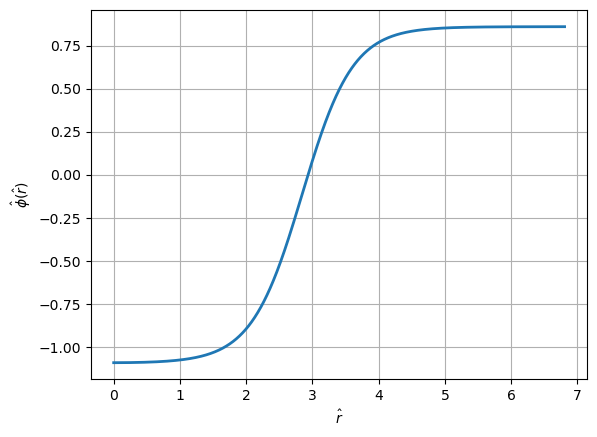

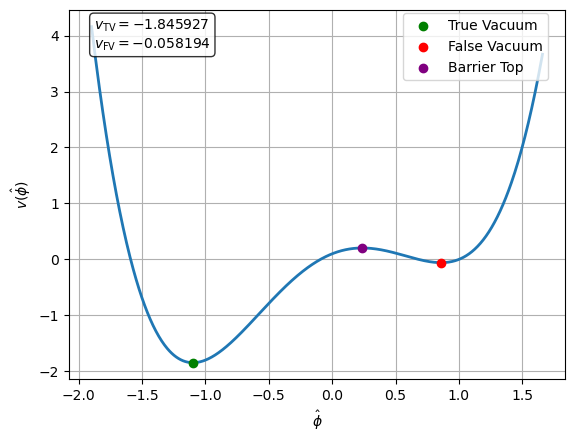

Runtime: 24.503280 seconds


In [48]:

#Overshoot/Undershoot#
import time
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import root_scalar
import matplotlib.pyplot as plt



#_____________________________________________
def v(phihat, kappa):
    return (phihat**2 - 1.0)**2 + kappa * (phihat - 1.0)


def dv(phihat, kappa):
    return 4.0 * phihat * (phihat**2 - 1.0) + kappa


def d2v(phihat, kappa):
    return 12.0 * phihat**2 - 4.0


def find_stationary_points(dvfun, args, phi_min, phi_max, n_scan=6000):
    phi_grid = np.linspace(phi_min, phi_max, n_scan + 1)
    vals = dvfun(phi_grid, *args)

    roots = []

    for i in range(n_scan):
        f1 = vals[i]
        f2 = vals[i + 1]

        if not np.isfinite(f1) or not np.isfinite(f2):
            continue

        if f1 == 0.0:
            bracket = (phi_grid[i] - 1e-3, phi_grid[i] + 1e-3)
        elif f1 * f2 < 0:
            bracket = (phi_grid[i], phi_grid[i + 1])
        else:
            continue

        try:
            sol = root_scalar(
                lambda x: dvfun(x, *args),
                bracket=bracket,
                method="brentq",
                xtol=1e-14
            )
            roots.append(sol.root)
        except Exception:
            pass

    roots = np.array(sorted(roots))

    unique_roots = []
    for r in roots:
        if not unique_roots or abs(r - unique_roots[-1]) > 1e-6:
            unique_roots.append(r)

    return np.array(unique_roots)


def find_vacua(vfun, dvfun, d2vfun, args, phi_min, phi_max):
    stationary = find_stationary_points(dvfun, args, phi_min, phi_max)

    minima = []
    for x in stationary:
        if d2vfun(x, *args) > 0:
            minima.append((x, vfun(x, *args)))

    if len(minima) < 2:
        raise RuntimeError("Need at least two minima.")

    minima.sort(key=lambda t: t[1])

    (phi_true, v_true), (phi_false, v_false) = minima[0], minima[1]
    return phi_true, phi_false, v_true, v_false


def find_barrier_top(dvfun, d2vfun, args, phi_min, phi_max):
    stationary = find_stationary_points(dvfun, args, phi_min, phi_max)
    maxima = [x for x in stationary if d2vfun(x, *args) < 0]

    if not maxima:
        return None

    maxima = sorted(maxima)
    return maxima[len(maxima) // 2]


def bounce_ode(rhat, y, dvfun, args):
    phihat, dphihat = y
    friction = 0.0 if rhat == 0.0 else 3.0 / rhat
    return [dphihat, dvfun(phihat, *args) - friction * dphihat]


def solve_bounce(phi0, rhat_max, dvfun, args, nsteps=4000):
    r0 = 1e-6

    sol = solve_ivp(
        lambda rhat, y: bounce_ode(rhat, y, dvfun, args),
        (r0, rhat_max),
        [phi0, 0.0],
        max_step=rhat_max / nsteps,
        rtol=1e-9,
        atol=1e-12
    )

    return sol.t, sol.y[0], sol.y[1]


def shoot_F(phi0, rhat_max, dvfun, args, phi_false):
    rhat, phihat, dphihat = solve_bounce(phi0, rhat_max, dvfun, args)
    return phihat[-1] - phi_false


def find_phi0(phi_true, phi_false, rhat_max, dvfun, args):
    delta = 1e-4
    lo = phi_true + delta
    hi = phi_false - delta

    trial_phi0 = np.linspace(lo, hi, 80)
    F_vals = np.array([shoot_F(x, rhat_max, dvfun, args, phi_false) for x in trial_phi0])

    bracket = None
    for i in range(len(trial_phi0) - 1):
        if F_vals[i] * F_vals[i + 1] < 0:
            bracket = (trial_phi0[i], trial_phi0[i + 1])
            break

    if bracket is None:
        raise RuntimeError("No sign change found in the shooting function.")

    sol = root_scalar(
        lambda x: shoot_F(x, rhat_max, dvfun, args, phi_false),
        bracket=bracket,
        method="brentq",
        xtol=1e-10
    )

    return sol.root


def action_s4_dimless(rhat, phihat, dphihat, vfun, args, v_false):
    integrand = 0.5 * dphihat**2 + vfun(phihat, *args) - v_false
    return 2.0 * np.pi**2 * np.trapz(integrand * rhat**3, rhat)


def main():
    kappa = 0.9

    args = (kappa,)

    print("Dimensionless parameter:")
    print("kappa =", kappa)

    phi_min = -3.0
    phi_max = 3.0

    phihat_true, phihat_false, v_true, v_false = find_vacua(v, dv, d2v, args, phi_min, phi_max)
    phi_top = find_barrier_top(dv, d2v, args, phi_min, phi_max)

    print("phihat_true  =", phihat_true, "v_true  =", v_true)
    print("phihat_false =", phihat_false, "v_false =", v_false, "Delta v =", v_false - v_true)

    if phi_top is not None:
        print("phihat_top   =", phi_top, "v_top =", v(phi_top, *args))

    mf2_hat = d2v(phihat_false, *args)
    if mf2_hat <= 0:
        raise RuntimeError("False vacuum not stable.")

    rhat_max = 15.0 / np.sqrt(mf2_hat)

    phi0 = find_phi0(phihat_true, phihat_false, rhat_max, dv, args)
    print("phihat(0) =", phi0)

    rhat, phihat_r, dphihat_r = solve_bounce(phi0, rhat_max, dv, args)
    s4_hat = action_s4_dimless(rhat, phihat_r, dphihat_r, v, args, v_false)

    print("Dimensionless action s4_hat =", s4_hat)

    plt.figure()
    plt.plot(rhat, phihat_r, lw=2)
    plt.xlabel(r"$\hat{r}$")
    plt.ylabel(r"$\hat{\phi}(\hat{r})$")
    plt.grid(True)

    phihat_plot = np.linspace(
        min(phihat_true, phihat_false) - 0.8,
        max(phihat_true, phihat_false) + 0.8,
        800
    )

    plt.figure()
    plt.plot(phihat_plot, v(phihat_plot, *args), lw=2)

    plt.scatter([phihat_true], [v_true], color="green", zorder=3, label="True Vacuum")
    plt.scatter([phihat_false], [v_false], color="red", zorder=3, label="False Vacuum")

    if phi_top is not None:
        plt.scatter([phi_top], [v(phi_top, *args)], color="purple", zorder=3, label="Barrier Top")

    plt.xlabel(r"$\hat{\phi}$")
    plt.ylabel(r"$v(\hat{\phi})$")
    plt.grid(True)

    ax = plt.gca()
    ax.legend(loc="upper right", bbox_to_anchor=(0.98, 1.01))

    textstr = (
        rf"$v_{{\mathrm{{TV}}}} = {v_true:.6f}$" "\n"
        rf"$v_{{\mathrm{{FV}}}} = {v_false:.6f}$"
    )

    ax.text(
        0.05, 0.98,
        textstr,
        transform=ax.transAxes,
        fontsize=10,
        va="top",
        ha="left",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8, edgecolor="black")
    )

    plt.show()
#_____________________________________________

if __name__ == "__main__":
    start = time.perf_counter()
    main()
    end = time.perf_counter()
    print(f"Runtime: {end - start:.6f} seconds")